In [1]:
from pathlib import Path
import sys
from dataclasses import dataclass

src_path = Path.cwd().parent / "src"
sys.path.insert(0, str(src_path))

from main import *
from scipy.linalg import expm
from scipy.optimize import nnls

In [2]:
def dissipator_from_builder(builder, jump_operator):
    """
    Construct the Liouville-space matrix D[L] using the user's
    existing LiouvillianBuilder and Jump classes.
    """
    zero_H = np.zeros(
        (builder.d, builder.d),
        dtype=np.complex128,
    )

    return builder.build(
        zero_H,
        [Jump(jump_operator, 1.0)],
    )

def annihilation_operator(dim: int) -> np.ndarray:
    """
    Harmonic-oscillator lowering operator in a truncated Fock basis

        |0>, |1>, ..., |dim-1>.

    Matrix elements:
        <m|a|n> = sqrt(n) delta_{m,n-1}.
    """
    if dim < 1:
        raise ValueError("dim must be at least 1.")

    return np.diag(
        np.sqrt(np.arange(1, dim, dtype=float)),
        k=1,
    ).astype(np.complex128)


def creation_operator(dim: int) -> np.ndarray:
    """Truncated harmonic-oscillator raising operator a†."""
    return annihilation_operator(dim).conj().T

def thermal_harmonic_oscillator_model(
    dim: int,
    omega: float,
    beta: float,
    gamma: float,
):
    """
    Construct a time-independent thermal harmonic-oscillator model.

    Master equation:

        drho/dt = -i[H, rho]
                  + gamma*(nbar + 1)*D[a](rho)
                  + gamma*nbar*D[a†](rho).
    """
    if dim < 2:
        raise ValueError("dim must be at least 2.")
    if omega <= 0.0:
        raise ValueError("omega must be positive.")
    if beta <= 0.0:
        raise ValueError("beta must be positive.")
    if gamma < 0.0:
        raise ValueError("gamma must be non-negative.")

    a = annihilation_operator(dim)
    adag = a.conj().T
    number = adag @ a

    # The omitted omega/2 identity only contributes a global phase
    # and therefore drops out of [H, rho].
    H = omega * number

    nbar = 1.0 / np.expm1(beta * omega)

    def H_of_t(t):
        return H

    def jumps_of_t(t):
        return [
            Jump(a, gamma * (nbar + 1.0)),
            Jump(adag, gamma * nbar),
        ]

    model = LindbladModel2LS(H_of_t, jumps_of_t)
    return model, a, adag, nbar

# Function for finding it analytically according to the formula.
def thermal_rho_ss_and_derivative(dim, omega, beta):
    """
    Return rho_ss(beta) and d rho_ss / d beta for the truncated
    harmonic oscillator with H = omega * N.
    """
    a = annihilation_operator(dim)
    adag = creation_operator(dim)
    Nop = adag @ a

    rho_unnormalized = expm(-beta * omega * Nop)
    rho_ss = rho_unnormalized / np.trace(rho_unnormalized)

    mean_N = np.trace(Nop @ rho_ss).real
    drho_dbeta = -omega * (Nop - mean_N * np.eye(dim)) @ rho_ss

    # enforce Hermiticity numerically
    rho_ss = 0.5 * (rho_ss + rho_ss.conj().T)
    drho_dbeta = 0.5 * (drho_dbeta + drho_dbeta.conj().T)

    return rho_ss, drho_dbeta

In [4]:
dim = 10
omega = 1.0
beta = 0.1
gamma = 0.1

model, a, adag, nbar = thermal_harmonic_oscillator_model(
    dim=dim,
    omega=omega,
    beta=beta,
    gamma=gamma,
)

builder = LiouvillianBuilder(dim=dim)

H = model.H(0.0)
jumps = model.jumps(0.0)

L_total = builder.build(H, jumps)

print("Thermal occupation:", nbar)
print("Hamiltonian shape:", H.shape)
print("Liouvillian shape:", L_total.shape)

10
Thermal occupation: 9.50833194477505
Hamiltonian shape: (10, 10)
Liouvillian shape: (100, 100)


## 1. Example of tuning the temperature for CD
First we want to consider varying $\beta$. The best way to do this is to use the analytic solution. Then, once we find that, we want to consider
$$\partial_s \rho_{ss} = \mathcal{A}_s \rho_{ss}.$$

### QHO where we tune temperature of the bath
This example is particularly simple since 
1. We know the analytic solution.
2. We also have no rotation of the steady state, only dissipative part.

In [5]:
#---------------------
# Caclulate the target
#----------------------

N = adag @ a

rho_unnormalized = expm(-beta * omega * N)
rho_ss = rho_unnormalized / np.trace(rho_unnormalized)

mean_N = np.trace(N @ rho_ss).real

#Target for what action of superoperator should give.
drho_ss_dbeta = -omega * (
    N - mean_N * np.eye(N.shape[0])
) @ rho_ss

#---------------------
# Variational Calculation
#---------------------
hamiltonians = [N]
jump_operators = [a,adag@a]

x, gamma, residual_total, details = fit_overall_AGP(
    rho_ss,
    drho_ss_dbeta,
    hamiltonians,
    jump_operators,
    lam_unitary=0.0,
    lam_dissipative=10**(-12),
    return_details=True,
)

print("Fitted Hamiltonian coefficients (x):", x)
print("Fitted dissipative coefficients (gamma):", gamma)
print("Residual norm squared:", details["residual_total_norm_squared"])

# print(gamma)
# print("Residual norm squared:", results["residual_norm_squared"])
# print("Gamma norm squared:", results["gamma_norm_squared"])
# print("Theory value of gamma if we just have 'a':", omega/(1-np.exp(-beta*omega)))

Fitted Hamiltonian coefficients (x): [0.]
Fitted dissipative coefficients (gamma): [0.85144303 0.        ]
Residual norm squared: 0.5401871269097853


In [8]:
#Testing the AGP solver at a couple of values
dim = 3
beta=0.1
tau=0.001

a = annihilation_operator(dim)
adag = creation_operator(dim)
N = adag @ a

hamiltonians = [N]
jump_operators = [a]

rho_ss, drho_ss_dbeta=thermal_rho_ss_and_derivative(dim, 1.0, beta)

x, gamma, residual_total, details = fit_overall_AGP(
    rho_ss=rho_ss,
    partial_s_rho_ss=drho_ss_dbeta,
    hamiltonians=hamiltonians,
    jump_operators=jump_operators,
    lam_unitary=10**(-12),
    lam_dissipative=10**(-12),
    return_details=True,
)

print(x)
print(gamma)
print("Residual norm squared:", details["residual_total_norm_squared"])


[0.]
[0.55251453]
Residual norm squared: 0.0546189607562936


10
10


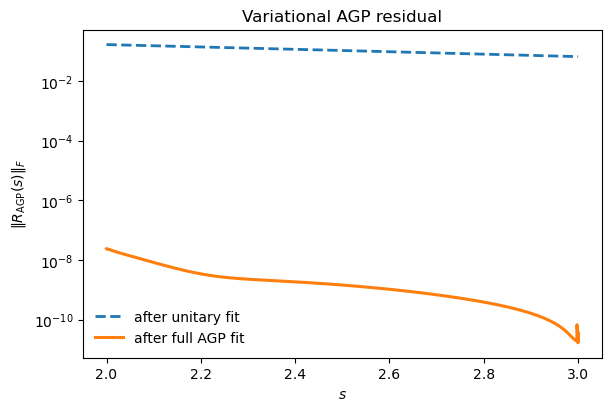

[2.42014146e-08 2.42119732e-08 2.42137401e-08 ... 1.95894950e-11
 3.85332425e-11 2.04384158e-11]


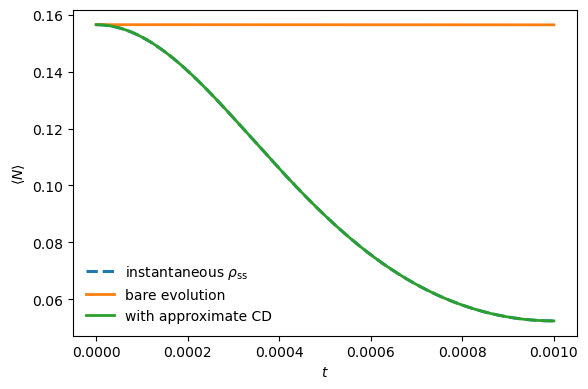

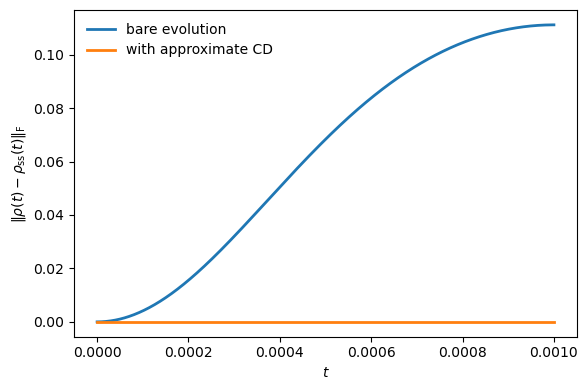

Final bare tracking error: 0.11113809428895527
Final CD tracking error: 1.4871007137410415e-07
Maximum bare tracking error: 0.11113809428895527
Maximum CD tracking error: 1.4871062448084808e-07


In [16]:
# ============================================================
# Approximate-CD trajectory for thermal harmonic oscillator
# ============================================================

# --------------------
# Easy parameters to tune
# --------------------
dim = 10
omega = 1.0
kappa = 1.0

#Pick sufficiently large beta given small dim.
beta0 = 2.0
beta1 = 3.0

tau = 0.001          # protocol duration: smaller = faster
nsteps = 1001       # number of AGP/evolution grid points

# --------------------
# Operators
# --------------------
a = annihilation_operator(dim)
adag = creation_operator(dim)
N = adag @ a

# --------------------
# Physical Lindblad model L(beta)
# --------------------
def H_of_beta(beta):
    return omega * N

def jumps_of_beta(beta):
    nbar = 1.0 / (np.exp(beta * omega) - 1.0)

    return [
        Jump(a,    kappa * (nbar + 1.0)),
        Jump(adag, kappa * nbar),
    ]

model = LindbladModel2LS(
    H_of_beta,
    jumps_of_beta,
)

# --------------------
# Protocol beta(t)
# --------------------
def beta_of_t(t):
    return beta0 + 0.5 * (beta1 - beta0) * (
        1.0 - np.cos(np.pi * t / tau)
    )
#Linear ramp
# def beta_of_t(t):
#     return beta0 + (beta1 - beta0) * t / tau

times = np.linspace(0.0, tau, nsteps)


# ============================================================
# Bare evolution under L(beta(t)), without the AGP
# ============================================================

def H_bare_of_t(t):
    return model.H(beta_of_t(t))


def jumps_bare_of_t(t):
    return model.jumps(beta_of_t(t))


bare_time_model = LindbladModel2LS(
    H_bare_of_t,
    jumps_bare_of_t,
)

builder = LiouvillianBuilder(
    dim=dim,
    vec_order="F",
)

# Use exactly the same initial state as the CD evolution.
rho0 = rho_ss_t[0]

bare_evolver = LindbladEvolver(
    bare_time_model,
    builder,
)

traj_bare = bare_evolver.simulate(
    rho0,
    t,
)

rho_bare_t = np.asarray([
    traj_bare.rho(k)
    for k in range(len(traj_bare.t))
])


# --------------------
# Variational AGP basis
# --------------------
hamiltonians = [N]#N]
jump_operators = [
    a,
    a@a,
]

# --------------------
# Run approximate-CD evolution
# --------------------
t, traj, rho_t, rho_ss_t, agp_data = approx_CD_trajectory(
    model,
    beta_of_t,
    times,
    hamiltonians,
    jump_operators,
    dim=dim,
    lam_unitary=1e-12,
    lam_dissipative=1e-12,
    plot_residual=True,
    residual_logscale=True,
)

print(agp_data["residual_norm"])

# ============================================================
# Compare bare, CD, and instantaneous steady-state trajectories
# ============================================================

N_ss = np.asarray([
    np.trace(rho @ N).real
    for rho in rho_ss_t
])

N_cd = np.asarray([
    np.trace(rho @ N).real
    for rho in rho_t
])

N_bare = np.asarray([
    np.trace(rho @ N).real
    for rho in rho_bare_t
])

plt.figure(figsize=(6, 4))

plt.plot(
    t,
    N_ss,
    "--",
    linewidth=2.2,
    label=r"instantaneous $\rho_{\rm ss}$",
)
plt.plot(
    t,
    N_bare,
    linewidth=2.0,
    label=r"bare evolution",
)
plt.plot(
    t,
    N_cd,
    linewidth=2.0,
    label=r"with approximate CD",
)

plt.xlabel(r"$t$")
plt.ylabel(r"$\langle N\rangle$")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


# ============================================================
# Density-matrix tracking errors
# ============================================================

tracking_error_bare = np.asarray([
    np.linalg.norm(rho - rho_ss, ord="fro")
    for rho, rho_ss in zip(rho_bare_t, rho_ss_t)
])

tracking_error_cd = np.asarray([
    np.linalg.norm(rho - rho_ss, ord="fro")
    for rho, rho_ss in zip(rho_t, rho_ss_t)
])

plt.figure(figsize=(6, 4))

plt.plot(
    t,
    tracking_error_bare,
    linewidth=2.0,
    label="bare evolution",
)
plt.plot(
    t,
    tracking_error_cd,
    linewidth=2.0,
    label="with approximate CD",
)

plt.xlabel(r"$t$")
plt.ylabel(
    r"$\|\rho(t)-\rho_{\rm ss}(t)\|_{\rm F}$"
)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

print(
    "Final bare tracking error:",
    tracking_error_bare[-1],
)
print(
    "Final CD tracking error:",
    tracking_error_cd[-1],
)
print(
    "Maximum bare tracking error:",
    np.max(tracking_error_bare),
)
print(
    "Maximum CD tracking error:",
    np.max(tracking_error_cd),
)

Maximum numerical/exact steady-state Frobenius error: 4.251729859509299e-15
Maximum numerical/exact steady-state trace distance: 3.166769292997581e-15
Maximum numerical/exact <N> error: 8.659739592076221e-15


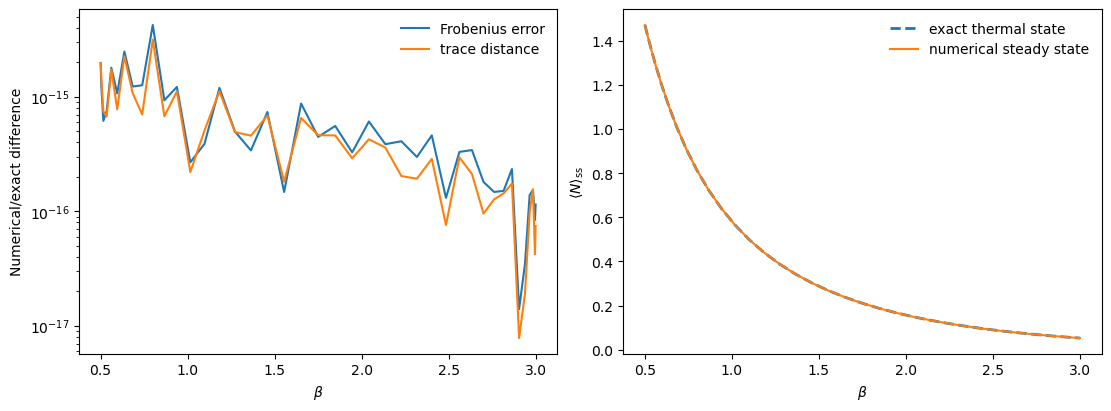

Maximum derivative Frobenius error: 0.0011398998342426409
Maximum relative derivative error: 0.0024926324584934167
Maximum interior derivative Frobenius error: 0.0011398998342426409
Maximum interior relative derivative error: 0.0024926324584934167


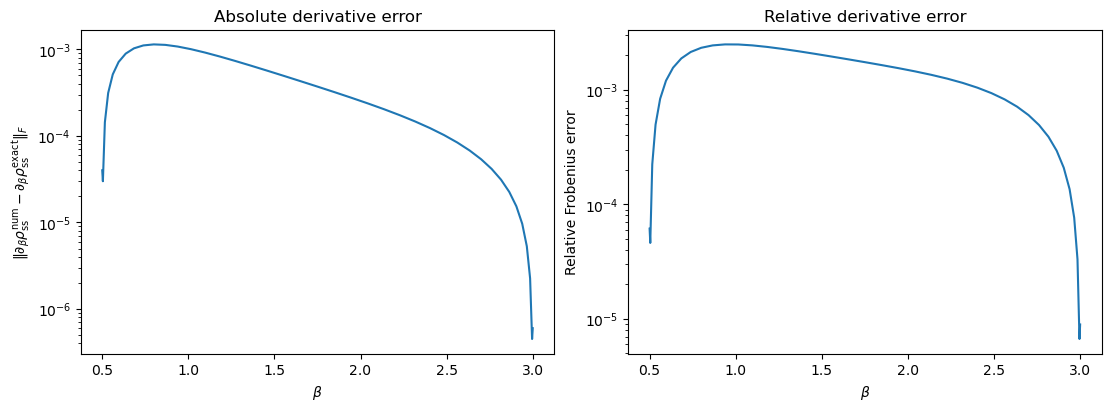

In [ ]:
# ============================================================
# Compare numerical and exact instantaneous steady states
# ============================================================


beta_t = agp_data["s"]

rho_ss_exact_t = np.array([
    thermal_rho_ss_and_derivative(dim, omega, beta)[0]
    for beta in beta_t
])

# Matrix difference:
# numerical steady state - exact truncated thermal state
rho_ss_difference = rho_ss_t - rho_ss_exact_t

# Frobenius-norm difference
rho_ss_frobenius_error = np.array([
    np.linalg.norm(delta, ord="fro")
    for delta in rho_ss_difference
])

# Trace-distance difference
rho_ss_trace_distance = np.array([
    0.5 * np.sum(
        np.abs(
            np.linalg.eigvalsh(
                0.5 * (delta + delta.conj().T)
            )
        )
    )
    for delta in rho_ss_difference
])

# Compare the corresponding mean occupations as an additional check
N_ss_exact = np.array([
    np.trace(rho @ N).real
    for rho in rho_ss_exact_t
])

N_ss_numerical = np.array([
    np.trace(rho @ N).real
    for rho in rho_ss_t
])

print(
    "Maximum numerical/exact steady-state Frobenius error:",
    np.max(rho_ss_frobenius_error),
)
print(
    "Maximum numerical/exact steady-state trace distance:",
    np.max(rho_ss_trace_distance),
)
print(
    "Maximum numerical/exact <N> error:",
    np.max(np.abs(N_ss_numerical - N_ss_exact)),
)

# Plot the state-level errors
fig, ax = plt.subplots(
    1,
    2,
    figsize=(11, 4),
    constrained_layout=True,
)

ax[0].plot(
    beta_t,
    rho_ss_frobenius_error,
    label="Frobenius error",
)
ax[0].plot(
    beta_t,
    rho_ss_trace_distance,
    label="trace distance",
)
ax[0].set_xlabel(r"$\beta$")
ax[0].set_ylabel("Numerical/exact difference")
ax[0].set_yscale("log")
ax[0].legend(frameon=False)

ax[1].plot(
    beta_t,
    N_ss_exact,
    "--",
    linewidth=2,
    label="exact thermal state",
)
ax[1].plot(
    beta_t,
    N_ss_numerical,
    linewidth=1.5,
    label="numerical steady state",
)
ax[1].set_xlabel(r"$\beta$")
ax[1].set_ylabel(r"$\langle N\rangle_{\rm ss}$")
ax[1].legend(frameon=False)

plt.show()

# ============================================================
# Compare numerical and exact beta derivatives
# ============================================================

drho_dbeta_exact_t = np.array([
    thermal_rho_ss_and_derivative(dim, omega, beta)[1]
    for beta in beta_t
])

# This was calculated numerically inside approx_CD_trajectory
# using np.gradient(rho_ss_t, s_t).
drho_dbeta_numerical_t = agp_data["drho_ds"]

drho_dbeta_difference = (
    drho_dbeta_numerical_t - drho_dbeta_exact_t
)

derivative_frobenius_error = np.array([
    np.linalg.norm(delta, ord="fro")
    for delta in drho_dbeta_difference
])

exact_derivative_norm = np.array([
    np.linalg.norm(drho, ord="fro")
    for drho in drho_dbeta_exact_t
])

relative_derivative_error = (
    derivative_frobenius_error
    / np.maximum(exact_derivative_norm, 1e-15)
)

print(
    "Maximum derivative Frobenius error:",
    np.max(derivative_frobenius_error),
)
print(
    "Maximum relative derivative error:",
    np.max(relative_derivative_error),
)

# Endpoint finite-difference errors are often larger, so also report
# the maximum error over interior grid points.
if len(beta_t) > 2:
    print(
        "Maximum interior derivative Frobenius error:",
        np.max(derivative_frobenius_error[1:-1]),
    )
    print(
        "Maximum interior relative derivative error:",
        np.max(relative_derivative_error[1:-1]),
    )

fig, ax = plt.subplots(
    1,
    2,
    figsize=(11, 4),
    constrained_layout=True,
)

ax[0].plot(
    beta_t,
    derivative_frobenius_error,
)
ax[0].set_xlabel(r"$\beta$")
ax[0].set_ylabel(
    r"$\|\partial_\beta\rho_{\rm ss}^{\rm num}"
    r"-\partial_\beta\rho_{\rm ss}^{\rm exact}\|_F$"
)
ax[0].set_yscale("log")
ax[0].set_title("Absolute derivative error")

ax[1].plot(
    beta_t,
    relative_derivative_error,
)
ax[1].set_xlabel(r"$\beta$")
ax[1].set_ylabel("Relative Frobenius error")
ax[1].set_yscale("log")
ax[1].set_title("Relative derivative error")

plt.show()

In [131]:
a = annihilation_operator(dim)
adag = creation_operator(dim)
Nop = adag @ a
H_bare = omega * Nop

hamiltonians = [
    Nop,
    a @ a + adag @ adag,
    1j * (adag @ adag - a @ a),
]

jump_operators = [
    a @ a,
    adag @ a,
]

n_times = 100
beta_i=0.3
beta_f=1.5

parameter_grid = np.linspace(beta_i, beta_f, n_times)
beta_of_t, betadot_of_t = linear_beta_schedule(beta_i, beta_f, T)

agp_data = precompute_overall_agp(
    parameter_grid=parameter_grid,
    rho_and_derivative=lambda beta: thermal_rho_ss_and_derivative(
        dim, omega, beta
    ),
    hamiltonians=hamiltonians,
    jump_operators=jump_operators,
    lam_unitary=0.0,
    lam_dissipative=0.0,
)

def bare_H_of_t(t):
    return H_bare

def bare_jumps_of_t(t):
    nbar = 1.0 / np.expm1(beta_of_t(t) * omega)
    return [
        Jump(a, bath_gamma * (nbar + 1.0)),
        Jump(adag, bath_gamma * nbar),
    ]

bare_model = LindbladModel2LS(
    bare_H_of_t,
    bare_jumps_of_t,
)

agp_model = build_overall_agp_model(
    bare_H_of_t=bare_H_of_t,
    bare_jumps_of_t=bare_jumps_of_t,
    parameter_of_t=beta_of_t,
    parameter_dot_of_t=betadot_of_t,
    agp_data=agp_data,
    hamiltonians=hamiltonians,
    jump_operators=jump_operators,
)

NameError: name 'beta_i' is not defined

In [ ]:
# ============================================================
# Small helpers
# ============================================================


def nearest_index(grid, x):
    idx = np.searchsorted(grid, x)
    if idx <= 0:
        return 0
    if idx >= len(grid):
        return len(grid) - 1
    if abs(x - grid[idx - 1]) <= abs(grid[idx] - x):
        return idx - 1
    return idx


def purity_of_rho(rho):
    return np.real(np.trace(rho @ rho))


def mean_number_of_rho(rho, Nop):
    return np.real(np.trace(Nop @ rho))


def trace_distance(rho, sigma):
    """
    Trace distance T(rho,sigma) = 1/2 ||rho-sigma||_1.
    Since rho-sigma is Hermitian, use eigvalsh.
    """
    delta = 0.5 * ((rho - sigma) + (rho - sigma).conj().T)
    eigs = np.linalg.eigvalsh(delta)
    return 0.5 * np.sum(np.abs(eigs))


def linear_beta_schedule(beta_i, beta_f, T):
    slope = (beta_f - beta_i) / T

    def beta_of_t(t):
        t_clip = min(max(float(t), 0.0), T)
        return beta_i + slope * t_clip

    def betadot_of_t(t):
        # valid because we only simulate on [0,T]
        return slope

    return beta_of_t, betadot_of_t


# ============================================================
# Precompute the variational CD coefficients on a time grid
# ============================================================

def precompute_variational_cd_data(
    dim,
    omega,
    t_eval,
    beta_of_t,
    jump_operators,
    lam=0.0,
):
    """
    For each time in t_eval:
      - build rho_ss(beta(t))
      - build d rho_ss / d beta
      - fit A_beta(rho_ss) ~ d rho_ss / d beta
    """
    rho_ss_list = []
    drho_dbeta_list = []
    gamma_cd_list = []
    residuals = []
    gamma_norms = []

    for t in t_eval:
        beta_t = beta_of_t(t)
        rho_ss, drho_dbeta = thermal_rho_ss_and_derivative(
            dim, omega, beta_t
        )

        gamma_cd, details = fit_dissipative_agp_nnls(
            rho_ss,
            drho_dbeta,
            jump_operators,
            lam=lam,
            return_details=True,
            verbose=False,
        )

        rho_ss_list.append(rho_ss)
        drho_dbeta_list.append(drho_dbeta)
        gamma_cd_list.append(gamma_cd)
        residuals.append(details["residual_norm_squared"])
        gamma_norms.append(details["gamma_norm_squared"])

    return {
        "rho_ss": np.array(rho_ss_list),
        "drho_dbeta": np.array(drho_dbeta_list),
        "gamma_cd": np.array(gamma_cd_list),
        "residuals": np.array(residuals),
        "gamma_norms": np.array(gamma_norms),
    }


# ============================================================
# Build bare and CD-corrected time-dependent models
# ============================================================

def build_bare_and_cd_models(
    dim,
    omega,
    bath_gamma,
    beta_of_t,
    betadot_of_t,
    t_eval,
    jump_operators,
    gamma_cd_grid,
):
    a = annihilation_operator(dim)
    adag = creation_operator(dim)
    Nop = adag @ a
    H = omega * Nop

    def H_of_t(t):
        return H

    def bare_jumps_of_t(t):
        beta_t = beta_of_t(t)
        nbar = 1.0 / np.expm1(beta_t * omega)

        return [
            Jump(a, bath_gamma * (nbar + 1.0)),
            Jump(adag, bath_gamma * nbar),
        ]

    def cd_jumps_of_t(t):
        jumps = bare_jumps_of_t(t)

        idx = nearest_index(t_eval, float(t))
        prefactor = betadot_of_t(t)
        gamma_cd = gamma_cd_grid[idx]

        # CD contribution: dot(beta) * sum_j gamma_j(beta) D[L_j]
        for L, g in zip(jump_operators, gamma_cd):
            rate = prefactor * g
            if abs(rate) > 0.0:
                jumps.append(Jump(L, rate))

        return jumps

    bare_model = LindbladModel2LS(H_of_t, bare_jumps_of_t)
    cd_model = LindbladModel2LS(H_of_t, cd_jumps_of_t)

    return bare_model, cd_model


# ============================================================
# Main plotting function
# ============================================================

def plot_variational_cd_performance(
    dim=12,
    omega=1.0,
    bath_gamma=1.0,
    beta_i=0.3,
    beta_f=1.5,
    T=2.0,
    n_times=250,
    lam=0.0,
    *,
    jump_operators=None,
    verbose=True,
):
    """
    Compare bare evolution against variational-CD-corrected evolution.

    Notes
    -----
    - Choose beta_f > beta_i so that dot(beta) > 0, otherwise the
      CD rates dot(beta)*gamma_j become negative and the correction
      is no longer GKSL.
    - If jump_operators is None, uses [a@a, adag@a].
    """

    if beta_f <= beta_i:
        raise ValueError(
            "For this GKSL CD construction, choose beta_f > beta_i "
            "so that dot(beta) > 0."
        )

    a = annihilation_operator(dim)
    adag = creation_operator(dim)
    Nop = adag @ a

    if jump_operators is None:
        # IMPORTANT: use a @ a, not a**2
        jump_operators = [a @ a, adag @ a]

    t_eval = np.linspace(0.0, T, n_times)
    beta_of_t, betadot_of_t = linear_beta_schedule(beta_i, beta_f, T)

    # Precompute the fitted CD coefficients gamma_j(beta(t))
    cd_data = precompute_variational_cd_data(
        dim=dim,
        omega=omega,
        t_eval=t_eval,
        beta_of_t=beta_of_t,
        jump_operators=jump_operators,
        lam=lam,
    )

    if verbose:
        print("Mean fit residual:", np.mean(cd_data["residuals"]))
        print("Max fit residual :", np.max(cd_data["residuals"]))
        print("Mean ||gamma||^2 :", np.mean(cd_data["gamma_norms"]))
        print("First fitted gamma vector:", cd_data["gamma_cd"][0])
        print("Last fitted gamma vector :", cd_data["gamma_cd"][-1])

    # Build bare and CD models
    bare_model, cd_model = build_bare_and_cd_models(
        dim=dim,
        omega=omega,
        bath_gamma=bath_gamma,
        beta_of_t=beta_of_t,
        betadot_of_t=betadot_of_t,
        t_eval=t_eval,
        jump_operators=jump_operators,
        gamma_cd_grid=cd_data["gamma_cd"],
    )

    builder = LiouvillianBuilder(dim=dim)
    evolver_bare = LindbladEvolver(bare_model, builder)
    evolver_cd = LindbladEvolver(cd_model, builder)

    # Initial state: exact initial instantaneous steady state
    rho0 = cd_data["rho_ss"][0]

    traj_bare = evolver_bare.simulate(rho0, t_eval)
    traj_cd = evolver_cd.simulate(rho0, t_eval)

    # Extract observables and distances
    rho_ss_t = cd_data["rho_ss"]

    n_ss = np.zeros(n_times)
    pur_ss = np.zeros(n_times)

    n_bare = np.zeros(n_times)
    pur_bare = np.zeros(n_times)
    dist_bare = np.zeros(n_times)

    n_cd = np.zeros(n_times)
    pur_cd = np.zeros(n_times)
    dist_cd = np.zeros(n_times)

    for k in range(n_times):
        rho_target = rho_ss_t[k]
        rho_bare = traj_bare.rho(k)
        rho_cd_k = traj_cd.rho(k)

        # small Hermitisation to suppress numerical noise
        rho_bare = 0.5 * (rho_bare + rho_bare.conj().T)
        rho_cd_k = 0.5 * (rho_cd_k + rho_cd_k.conj().T)

        n_ss[k] = mean_number_of_rho(rho_target, Nop)
        pur_ss[k] = purity_of_rho(rho_target)

        n_bare[k] = mean_number_of_rho(rho_bare, Nop)
        pur_bare[k] = purity_of_rho(rho_bare)
        dist_bare[k] = trace_distance(rho_bare, rho_target)

        n_cd[k] = mean_number_of_rho(rho_cd_k, Nop)
        pur_cd[k] = purity_of_rho(rho_cd_k)
        dist_cd[k] = trace_distance(rho_cd_k, rho_target)

    # ========================================================
    # Plot
    # ========================================================
    fig, ax = plt.subplots(1, 2, figsize=(11.0, 4.4), constrained_layout=True)

    # Left panel: path in observable space
    ax[0].plot(
        n_ss, pur_ss,
        "--",
        linewidth=2.2,
        label="instantaneous steady state",
    )
    ax[0].plot(
        n_bare, pur_bare,
        linewidth=2.2,
        label="bare evolution",
    )
    ax[0].plot(
        n_cd, pur_cd,
        linewidth=2.2,
        label="with variational CD",
    )

    ax[0].scatter([n_ss[0]], [pur_ss[0]], s=35, zorder=5, label="start")
    ax[0].scatter([n_ss[-1]], [pur_ss[-1]], s=35, zorder=5, label="end")

    ax[0].set_xlabel(r"$\langle N \rangle$")
    ax[0].set_ylabel(r"${\rm Tr}(\rho^2)$")
    ax[0].set_title("Path in state space")
    ax[0].legend(frameon=False)

    # Right panel: distance from instantaneous steady state
    ax[1].plot(
        t_eval, dist_bare,
        linewidth=2.2,
        label="bare evolution",
    )
    ax[1].plot(
        t_eval, dist_cd,
        linewidth=2.2,
        label="with variational CD",
    )

    ax[1].set_xlabel(r"$t$")
    ax[1].set_ylabel(r"$\frac{1}{2}\|\rho(t)-\rho_{\rm ss}(t)\|_1$")
    ax[1].set_title("Deviation from instantaneous steady state")
    ax[1].legend(frameon=False)

    plt.show()

    return {
        "t_eval": t_eval,
        "rho_ss_t": rho_ss_t,
        "traj_bare": traj_bare,
        "traj_cd": traj_cd,
        "gamma_cd_grid": cd_data["gamma_cd"],
        "fit_residuals": cd_data["residuals"],
        "fit_gamma_norms": cd_data["gamma_norms"],
        "dist_bare": dist_bare,
        "dist_cd": dist_cd,
        "n_ss": n_ss,
        "pur_ss": pur_ss,
        "n_bare": n_bare,
        "pur_bare": pur_bare,
        "n_cd": n_cd,
        "pur_cd": pur_cd,
    }

Mean fit residual: 0.008255874664658146
Max fit residual : 0.0779015111894696
Mean ||gamma||^2 : 3.8957076741352332
First fitted gamma vector: [2.98521788]
Last fitted gamma vector : [1.28721642]
12


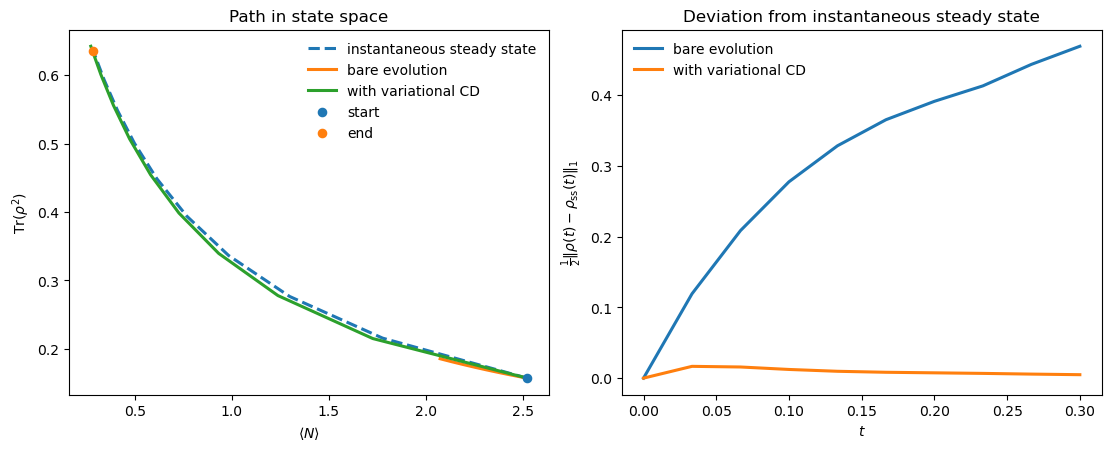

In [117]:
dim = 12
omega = 1.0
bath_gamma = 1.0

a = annihilation_operator(dim)
adag = creation_operator(dim)

results = plot_variational_cd_performance(
    dim=dim,
    omega=omega,
    bath_gamma=bath_gamma,
    beta_i=0.3,
    beta_f=1.5,   # choose beta_f > beta_i so dot(beta) > 0
    T=0.3,
    n_times=10,
    lam=0.0,
    jump_operators=[a],   # NOT a**2
    verbose=True,
)

### 2LS case

In [74]:
rho_ss=np.array([[1,0],[0,1]])/2
drho_ss=np.array([[1,0],[0,-1]])

jump_operators = [Pauli.sz, Pauli.sx, Pauli.sx+1.j*Pauli.sy]
    
gamma, results = fit_dissipative_agp_nnls(
    rho_ss,
    drho_ss,
    jump_operators,
    lam=0.0,
    return_details=True,
)

print(gamma)
print("Residual norm squared:", results["residual_norm_squared"])
print("Gamma norm squared:", results["gamma_norm_squared"])

[0.  0.  0.5]
Residual norm squared: 0.0
Gamma norm squared: 0.25


### Old hardcoded version

In [ ]:
#----------------------
# Calculate the AGP variationally
#----------------------
def fit_single_dissipator(
    builder,
    rho,
    drho,
    jump_operator,
):
    """
    Solve

        min_c ||drho - c D[L](rho)||_F

    for a real scalar c.
    """
    D = dissipator_from_builder(
        builder,
        jump_operator,
    )

    rho_vec = builder.vec(rho)
    target = builder.vec(drho)

    # Direction in operator space generated by D[L]
    direction = D @ rho_vec

    denominator = np.vdot(
        direction,
        direction,
    ).real

    if denominator < 1e-15:
        raise ValueError(
            "D[L](rho) is numerically zero, so the coefficient "
            "cannot be determined."
        )

    coefficient = (
        np.vdot(direction, target).real
        / denominator
    )

    fitted_target = coefficient * direction
    residual = target - fitted_target

    return {
        "coefficient": coefficient,
        "dissipator": D,
        "superoperator": coefficient * D,
        "fitted_derivative": builder.mat(fitted_target),
        "residual": builder.mat(residual),
        "residual_norm": np.linalg.norm(residual),
        "relative_residual": (
            np.linalg.norm(residual)
            / np.linalg.norm(target)
        ),
    }

result = fit_single_dissipator(
    builder,
    rho_ss,
    drho_ss_dbeta,
    a,
)

print("Optimal coefficient:")
print(result["coefficient"])

print("Residual norm:")
print(result["residual_norm"])

print("Relative residual:")
print(result["relative_residual"])


(1-9.860761315262648e-32j)


/var/folders/h3/s252cnjs1fg5q_2y8x3vh8mr0000gp/T/ipykernel_83807/2655252996.py:4: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(rhoss_num)))


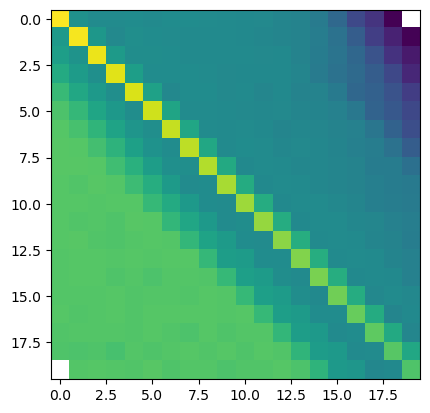

/var/folders/h3/s252cnjs1fg5q_2y8x3vh8mr0000gp/T/ipykernel_83807/2655252996.py:8: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(rhoss)))


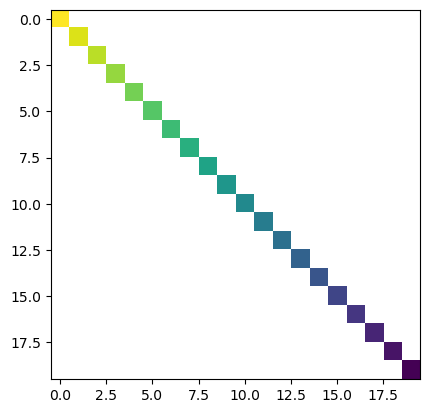

Error in numerics vs. analytics for rho_ss
4.3798335016052187e-14


In [36]:
#Calculate the steady state numerically
rhoss_num=get_steady_state(builder, model, 0.0)
print(np.trace(rhoss_num))
plt.imshow(np.log(np.abs(rhoss_num)))
plt.show()
M=expm(-beta*omega*(adag@a))
rhoss=M/np.trace(M)
plt.imshow(np.log(np.abs(rhoss)))
plt.show()
print("Error in numerics vs. analytics for rho_ss")
print(np.sum(np.abs(rhoss_num-rhoss)))